In [1]:
import pandas as pd
df=pd.read_csv('raw_data.csv')

In [2]:
df

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0


In [23]:
df2=df.copy()
df2

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0


In [26]:
df2['income']=df2['income'].fillna(10)

In [27]:
df2['tax']= df2['income'].apply(lambda x : '20%' if x>=60000 else '10%')
df2

,id,name,age,country,gender,income,tax
0,1,John Doe,29.0,USA,Male,55000.0,10%
1,1,John Doe,29.0,USA,Male,55000.0,10%
2,2,Jane Smith,NaN,Canada,Female,62000.0,20%
3,3,Alex,NaN,USA,Unknown,47000.0,10%
4,4,Maria Garcia,34.0,Spain,Female,10.0,10%
5,5,Li Wei,27.0,China,Male,51000.0,10%
6,6,NaN,45.0,India,Female,73000.0,20%
7,7,Ahmed Khan,38.0,NaN,Male,68000.0,20%
8,8,Rachel Lee,29.0,USA,Female,62000.0,20%
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0,10%


In [28]:
# maping
gend={'Male':'M', 'Female':'F', 'Unknown':'N'}
df2['gender']=df2['gender'].map(gend)

In [29]:
df2['country']=df2['country'].replace('USA', 'United State')

In [30]:
df2=df2.assign(new=df2['income'] * 1.2)

In [31]:
df2

,id,name,age,country,gender,income,tax,new
0,1,John Doe,29.0,United State,M,55000.0,10%,66000.0
1,1,John Doe,29.0,United State,M,55000.0,10%,66000.0
2,2,Jane Smith,NaN,Canada,F,62000.0,20%,74400.0
3,3,Alex,NaN,United State,N,47000.0,10%,56400.0
4,4,Maria Garcia,34.0,Spain,F,10.0,10%,12.0
5,5,Li Wei,27.0,China,M,51000.0,10%,61200.0
6,6,NaN,45.0,India,F,73000.0,20%,87600.0
7,7,Ahmed Khan,38.0,NaN,M,68000.0,20%,81600.0
8,8,Rachel Lee,29.0,United State,F,62000.0,20%,74400.0
9,9,Carlos Ruiz,NaN,Mexico,M,45000.0,10%,54000.0


In [53]:
# df.rename(columns={'income': 'salery'})
# df.columns=coulums=['id','Country','Name','Age','Gender', 'Salery']
df=df.fillna(100)
df=df.sort_values('Salery')    # salery column ke salery ko ascending order me leko
# df.sort_index()  # opar wale salery me jo index gar bar hoye te dobara osko apne original form me karo
df.reset_index()   # porane gar bar index ka alag column banawo our dosre index leko jo zero se start ho 
df.reset_index(drop=True)   # matlab sorting me jo indexes gar bar ho gaye te osko delet kar do

,id,Country,Name,Age,Gender,Salery
0,4,Maria Garcia,34.0,Spain,Female,100.0
1,9,Carlos Ruiz,100.0,Mexico,Male,45000.0
2,3,Alex,100.0,USA,Unknown,47000.0
3,5,Li Wei,27.0,China,Male,51000.0
4,1,John Doe,29.0,USA,Male,55000.0
5,1,John Doe,29.0,USA,Male,55000.0
6,10,Emily Davis,31.0,USA,100,58000.0
7,2,Jane Smith,100.0,Canada,Female,62000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,7,Ahmed Khan,38.0,100,Male,68000.0


In [57]:
df['Ranking']=df['Salery'].rank(ascending=False , method='dense')
df

,id,Country,Name,Age,Gender,Salery,Ranking
4,4,Maria Garcia,34.0,Spain,Female,100.0,9.0
9,9,Carlos Ruiz,100.0,Mexico,Male,45000.0,8.0
3,3,Alex,100.0,USA,Unknown,47000.0,7.0
5,5,Li Wei,27.0,China,Male,51000.0,6.0
1,1,John Doe,29.0,USA,Male,55000.0,5.0
0,1,John Doe,29.0,USA,Male,55000.0,5.0
10,10,Emily Davis,31.0,USA,100,58000.0,4.0
2,2,Jane Smith,100.0,Canada,Female,62000.0,3.0
8,8,Rachel Lee,29.0,USA,Female,62000.0,3.0
7,7,Ahmed Khan,38.0,100,Male,68000.0,2.0


In [58]:
# TASK is to shift id column to the end using list comprehension method 
df2=df.copy()

In [61]:
new=[col for col in df2.columns if col !='id'] + ['id']
new

['Country', 'Name', 'Age', 'Gender', 'Salery', 'Ranking', 'id']

In [62]:
df2[new]

,Country,Name,Age,Gender,Salery,Ranking,id
4,Maria Garcia,34.0,Spain,Female,100.0,9.0,4
9,Carlos Ruiz,100.0,Mexico,Male,45000.0,8.0,9
3,Alex,100.0,USA,Unknown,47000.0,7.0,3
5,Li Wei,27.0,China,Male,51000.0,6.0,5
1,John Doe,29.0,USA,Male,55000.0,5.0,1
0,John Doe,29.0,USA,Male,55000.0,5.0,1
10,Emily Davis,31.0,USA,100,58000.0,4.0,10
2,Jane Smith,100.0,Canada,Female,62000.0,3.0,2
8,Rachel Lee,29.0,USA,Female,62000.0,3.0,8
7,Ahmed Khan,38.0,100,Male,68000.0,2.0,7


# Cleaning data and saving it in CSV or json file   Lecture 4

In [65]:
df2=df2.drop_duplicates()

In [66]:
df2=df2.reset_index(drop=True)

In [67]:
df2

,id,Country,Name,Age,Gender,Salery,Ranking
0,4,Maria Garcia,34.0,Spain,Female,100.0,9.0
1,9,Carlos Ruiz,100.0,Mexico,Male,45000.0,8.0
2,3,Alex,100.0,USA,Unknown,47000.0,7.0
3,5,Li Wei,27.0,China,Male,51000.0,6.0
4,1,John Doe,29.0,USA,Male,55000.0,5.0
5,10,Emily Davis,31.0,USA,100,58000.0,4.0
6,2,Jane Smith,100.0,Canada,Female,62000.0,3.0
7,8,Rachel Lee,29.0,USA,Female,62000.0,3.0
8,7,Ahmed Khan,38.0,100,Male,68000.0,2.0
9,6,100,45.0,India,Female,73000.0,1.0


In [69]:
df2.to_csv('Clean_Data.csv')    # for json write df2.to_json

In [74]:
#   Grouping and aggregation   lecture 5

df2.groupby('Age')['Salery'].mean()

Age
100       68000.0
Canada    62000.0
China     51000.0
India     73000.0
Mexico    45000.0
Spain       100.0
USA       55500.0
Name: Salery, dtype: float64

In [77]:
df2.groupby('Age')['Salery'].agg({'mean', 'max', 'min'})     # OR YOU CAN ALSO WRITE IS AS BELOW TO RENAME THE COLUMN
df2.groupby('Age')['Salery'].agg(Avg_Sal='mean', Max_Sal='max', Min_Sal='min')

,Avg_Sal,Max_Sal,Min_Sal
Age,,,
100,68000.0,68000.0,68000.0
Canada,62000.0,62000.0,62000.0
China,51000.0,51000.0,51000.0
India,73000.0,73000.0,73000.0
Mexico,45000.0,45000.0,45000.0
Spain,100.0,100.0,100.0
USA,55500.0,62000.0,47000.0


In [84]:
df2=df.copy()

In [90]:
df2= df2.rename(columns={'Age':'Country'})
df2= df2.rename(columns={'Name':'Age'})
df2= df2.rename(columns={'Country':'Name'})

In [97]:
df2= df2.rename(columns={1:'Name'})

In [100]:
df2.columns = ['id', 'Name', 'Age', 'Country', 'Gender', 'Salery', 'Ranking']

In [101]:
df2.groupby('Country').agg({
    'Salery':'mean',
    'Age' : 'mean'
})

,Salery,Age
Country,,
100,68000.0,38.0
Canada,62000.0,100.0
China,51000.0,27.0
India,73000.0,45.0
Mexico,45000.0,100.0
Spain,100.0,34.0
USA,55400.0,43.6


<Axes: xlabel='Name'>

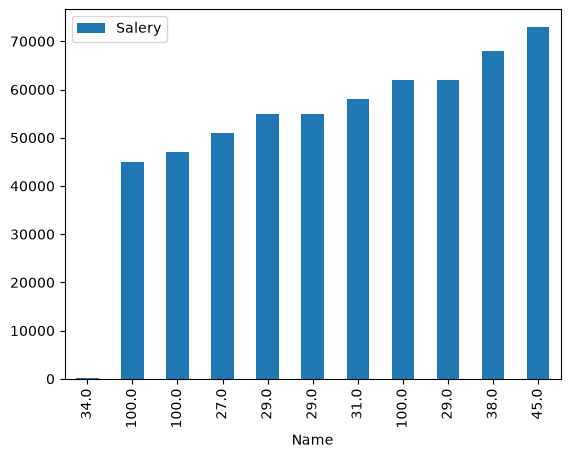

In [103]:
# Basic visuillization with pandas
df.plot(kind='bar', x='Name', y='Salery')

In [107]:
#   Merging and joining 

data1=pd.DataFrame({
    'id': [1,2,3,4,5],
    'name':['adam', 'tom', 'bob', 'Hamza', 'usman']
})

data2=pd.DataFrame({
    'order': [102,103,104,105,106],
    'id': [1,2,7,4,5],
    'amount':[203,2034,20304,2595,4045]
})

In [108]:
data1

,id,name
0,1,adam
1,2,tom
2,3,bob
3,4,Hamza
4,5,usman


In [109]:
data2

,order,id,amount
0,102,1,203
1,103,2,2034
2,104,7,20304
3,105,4,2595
4,106,5,4045


In [110]:
merge=pd.merge(data1,data2, on='id')

In [111]:
merge

,id,name,order,amount
0,1,adam,102,203
1,2,tom,103,2034
2,4,Hamza,105,2595
3,5,usman,106,4045


In [114]:
merge1=pd.merge(data1,data2, on='id', how='left')  # also place in place of left (right or outer both work lettle bit different than this)
merge1

,id,name,order,amount
0,1,adam,102.0,203.0
1,2,tom,103.0,2034.0
2,3,bob,NaN,NaN
3,4,Hamza,105.0,2595.0
4,5,usman,106.0,4045.0


In [115]:
# data concatination
df1=pd.DataFrame({
    'id':[1,2,3,4],
    'name':['adam', 'bob', 'tom', 'eve']
})
df2=pd.DataFrame({
    'id':[5,6,7,8],
    'name':['Hamza', 'jhon', 'sena', 'evil']
})



In [116]:
pd.concat([df1,df2])   # row wise concatination (on top of each other)

,id,name
0,1,adam
1,2,bob
2,3,tom
3,4,eve
0,5,Hamza
1,6,jhon
2,7,sena
3,8,evil


In [117]:
pd.concat([df1,df2],axis=1)   # column wise concatination (side by side concatination)

,id,name,id,name
0,1,adam,5,Hamza
1,2,bob,6,jhon
2,3,tom,7,sena
3,4,eve,8,evil
